**Importing Necessary Dependencies**

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Collection**

In [182]:
# load the dataset into a pandas DataFrame
df = pd.read_csv("../dataset/clean dataset/telco_customer_churn_cleaned_dataset.csv")

In [183]:
# display first 5 rows of the dataset
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paper_less_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [184]:
df.shape

(7032, 21)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         7032 non-null   object 
 1   gender              7032 non-null   object 
 2   senior_citizen      7032 non-null   int64  
 3   partner             7032 non-null   object 
 4   dependents          7032 non-null   object 
 5   tenure              7032 non-null   int64  
 6   phone_service       7032 non-null   object 
 7   multiple_lines      7032 non-null   object 
 8   internet_service    7032 non-null   object 
 9   online_security     7032 non-null   object 
 10  online_backup       7032 non-null   object 
 11  device_protection   7032 non-null   object 
 12  tech_support        7032 non-null   object 
 13  streaming_tv        7032 non-null   object 
 14  streaming_movies    7032 non-null   object 
 15  contract            7032 non-null   object 
 16  paper_

In [186]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [187]:
df.duplicated().sum()

np.int64(0)

In [188]:
df.isnull().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paper_less_billing    0
payment_method        0
monthly_charges       0
total_charges         0
churn                 0
dtype: int64

## **Exploratory Data Analysis (EDA)**

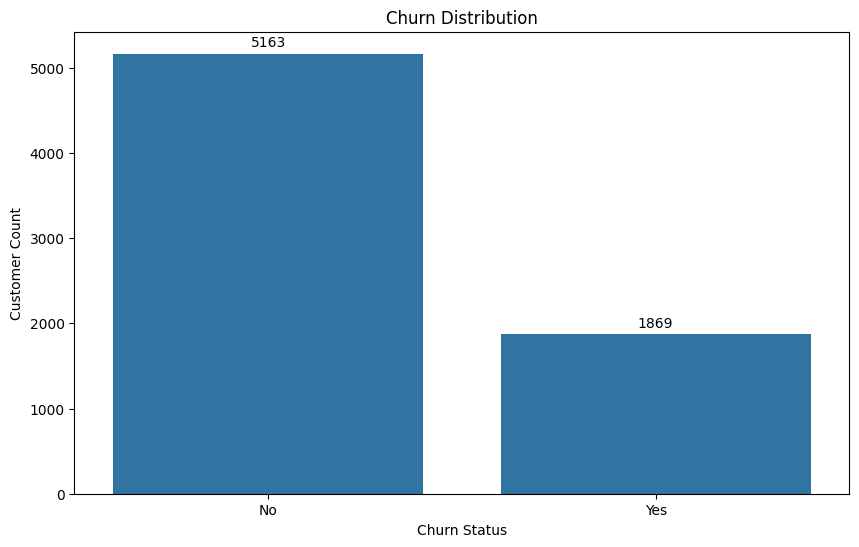

In [189]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="churn", data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
plt.show()

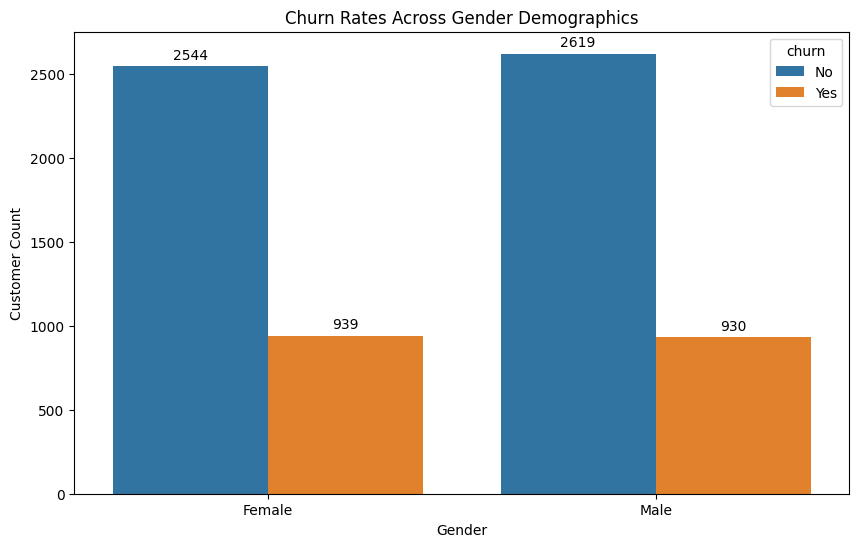

In [190]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="gender", hue='churn', data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Rates Across Gender Demographics")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

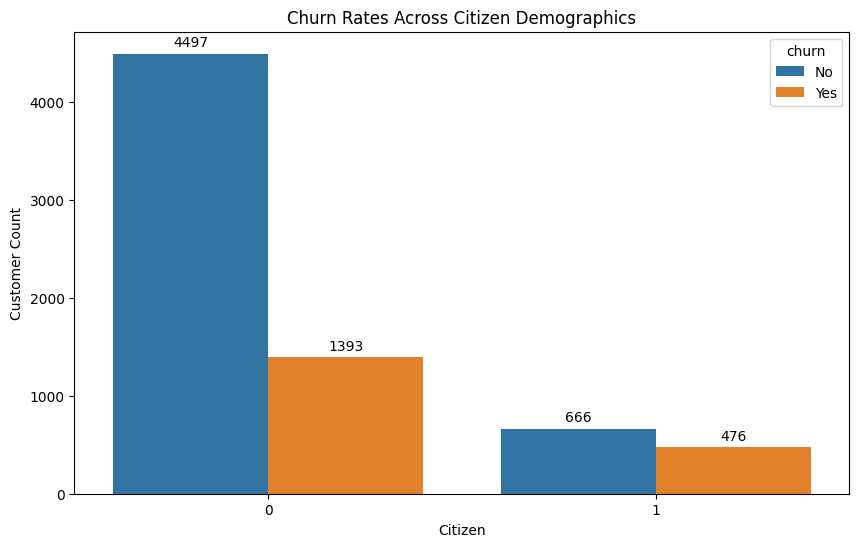

In [191]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="senior_citizen", hue='churn', data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Rates Across Citizen Demographics")
plt.xlabel("Citizen")
plt.ylabel("Customer Count")
plt.show()

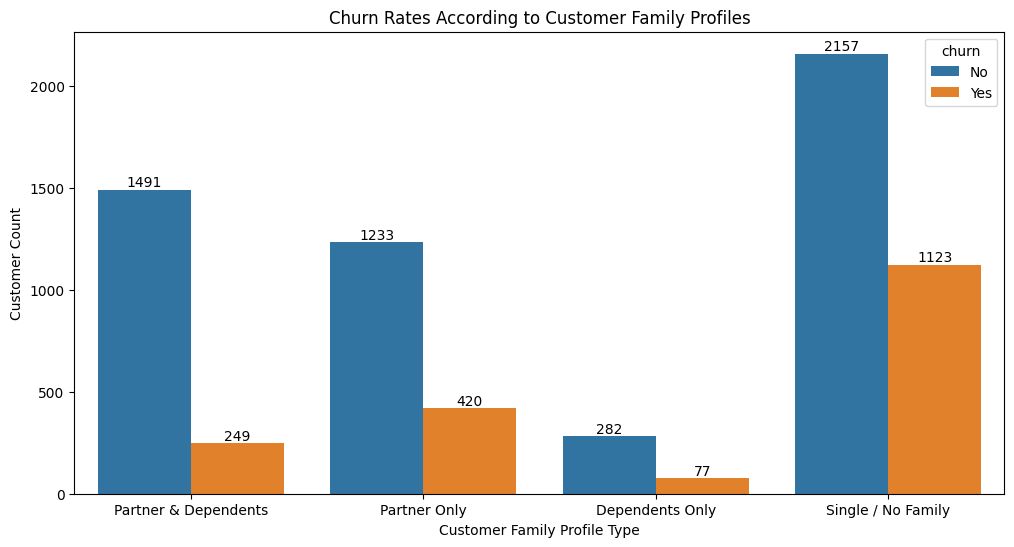

In [192]:
def get_customer_profile(row):
    if row['partner'] == 'Yes' and row['dependents'] == 'Yes':
        return 'Partner & Dependents'
    
    elif row['partner'] == 'Yes' and row['dependents'] == 'No':
        return 'Partner Only'
    
    elif row['partner'] == 'No' and row['dependents'] == 'Yes':
        return 'Dependents Only'
    
    else:
        return 'Single / No Family'

df['customer_profile'] = df.apply(get_customer_profile, axis=1)

plt.figure(figsize=(12,6))
ax= sns.countplot(x='customer_profile', hue='churn', data=df, order = ['Partner & Dependents', 'Partner Only', 'Dependents Only', 'Single / No Family'])

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Churn Rates According to Customer Family Profiles")
plt.xlabel("Customer Family Profile Type")
plt.ylabel("Customer Count")
plt.show()

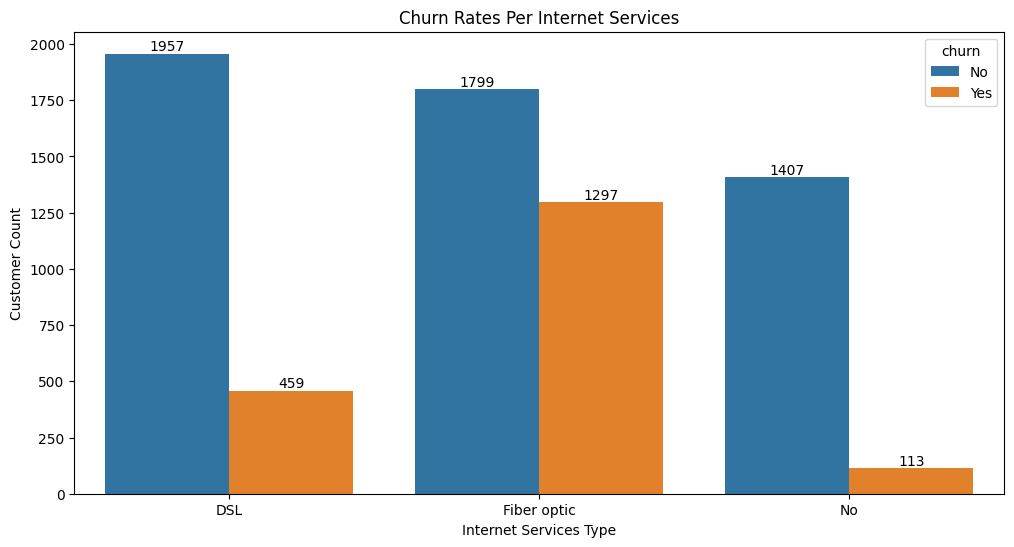

In [193]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="internet_service", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Churn Rates Per Internet Services")
plt.xlabel("Internet Services Type")
plt.ylabel("Customer Count")
plt.show()

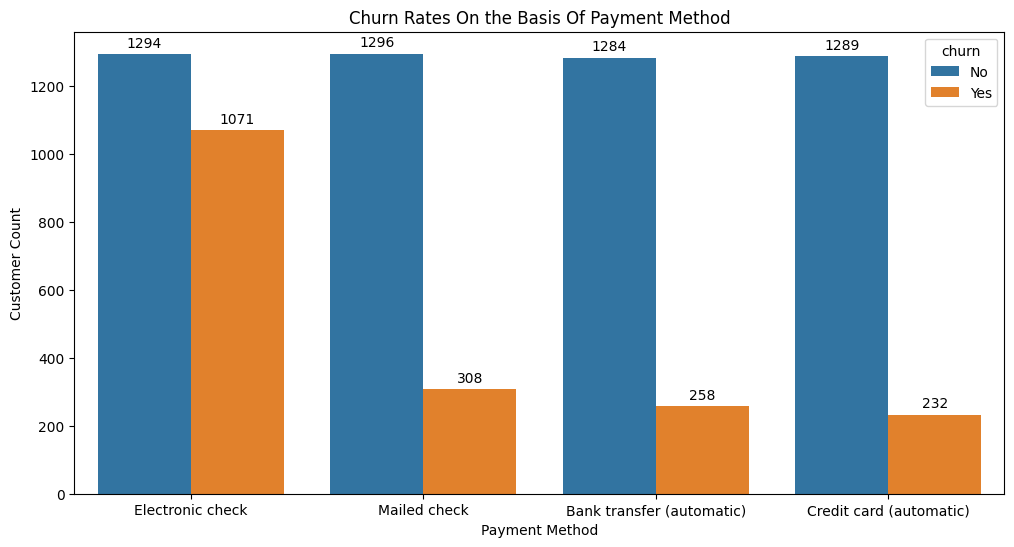

In [194]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="payment_method", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Churn Rates On the Basis Of Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.show()

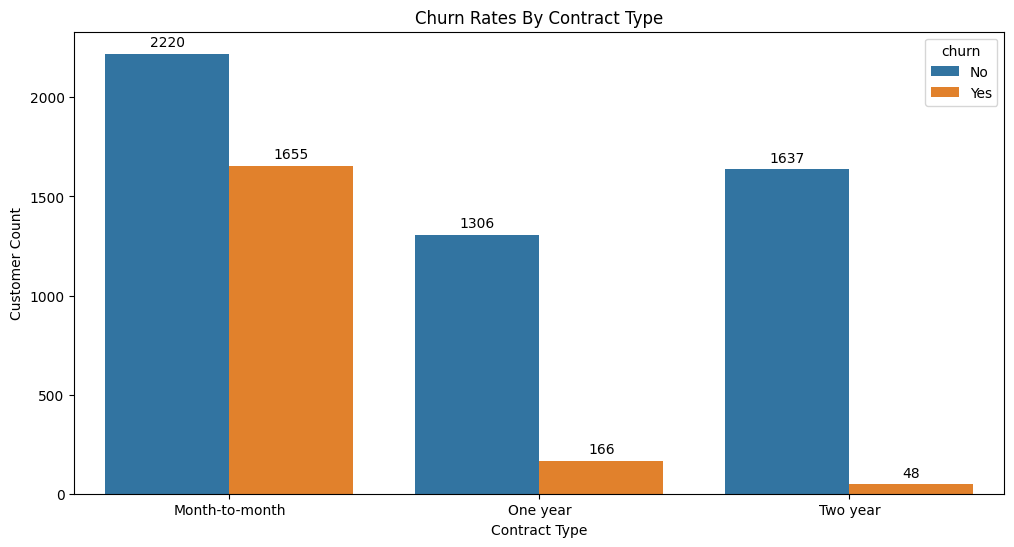

In [195]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="contract", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Churn Rates By Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()

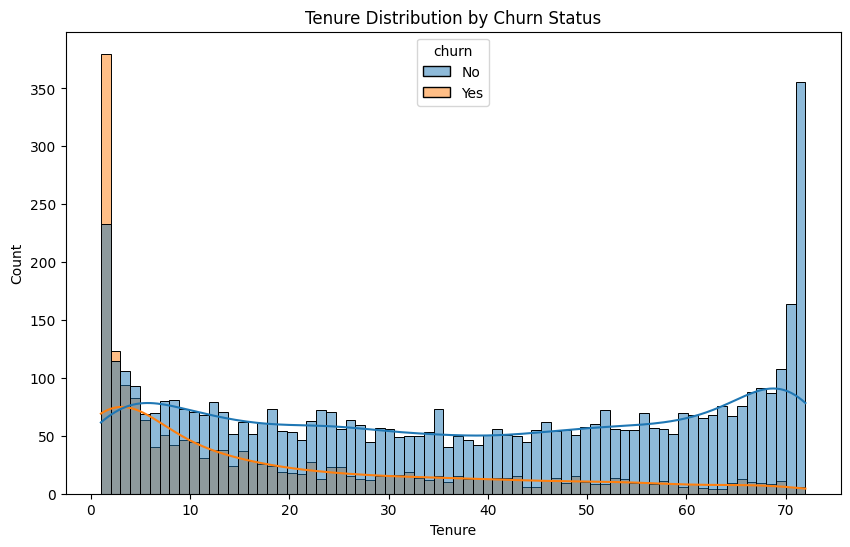

In [196]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='tenure', hue='churn', bins=72, kde=True)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()

In [197]:
# Convert 'churn' into a numerical value (0 and 1) so the correlation matrix can read it
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No':0})

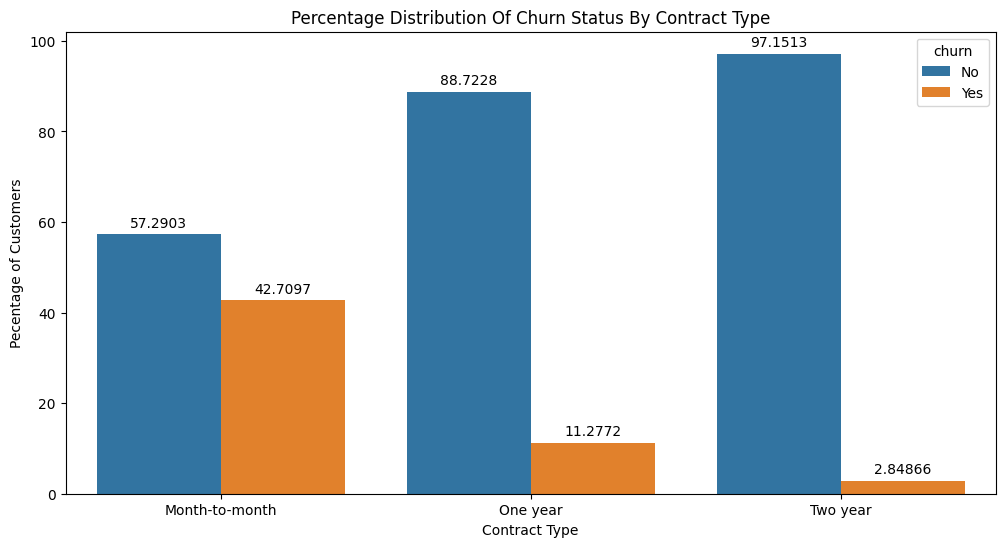

In [198]:
contract_churn =  df.groupby('contract')['churn'].value_counts(normalize=True).rename('churn_percentage').reset_index()
contract_churn['churn_percentage'] = contract_churn['churn_percentage'] * 100

plt.figure(figsize=(12.,6))
ax=sns.barplot(data= contract_churn, x="contract", y='churn_percentage', hue='churn', order = ['Month-to-month', 'One year', 'Two year'])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Percentage Distribution Of Churn Status By Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Pecentage of Customers")
plt.show()

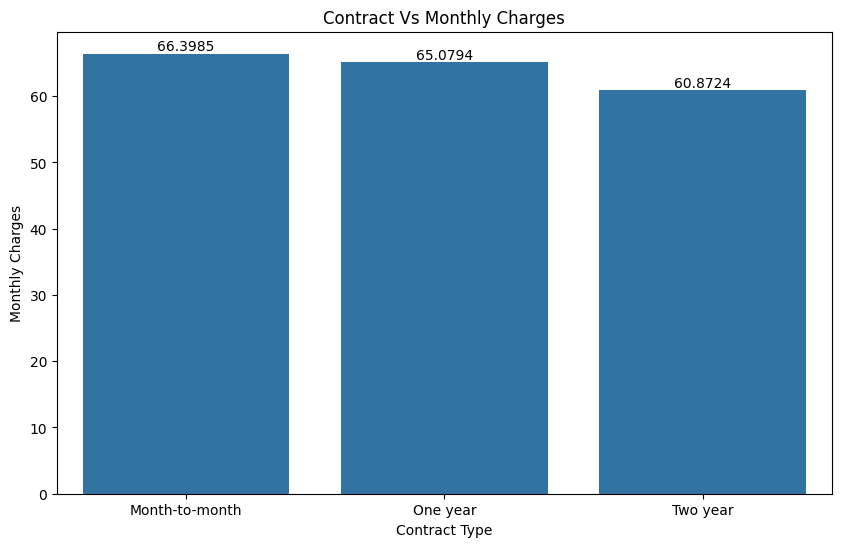

In [199]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x="contract", y="monthly_charges", data=df, errorbar = None)
 
for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Contract Vs Monthly Charges")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")
plt.show()

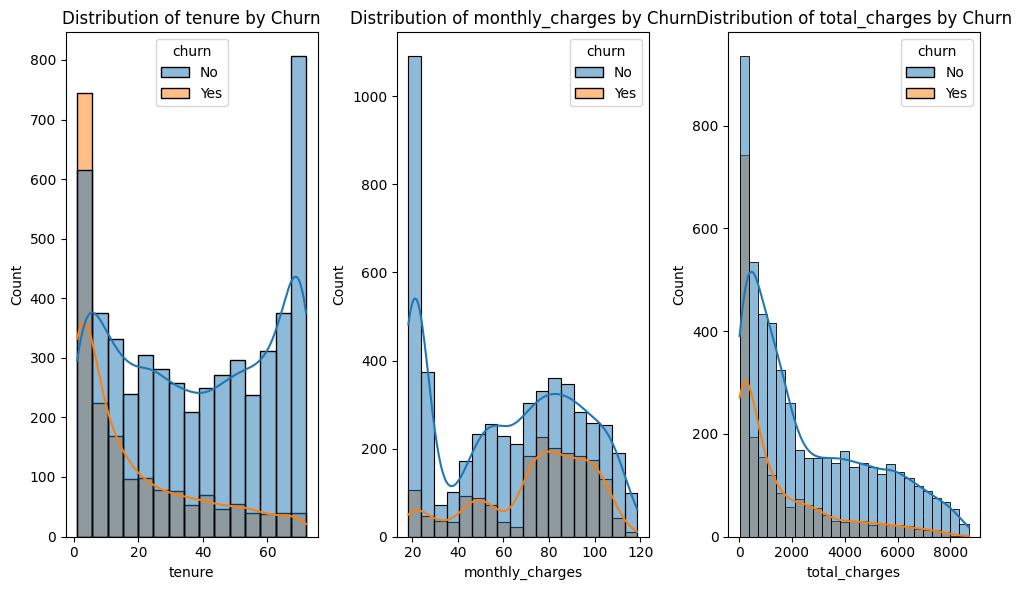

In [200]:
fig, axes = plt.subplots(1, 3, figsize=(10,6))
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='churn', kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by Churn")

plt.tight_layout()
plt.show()

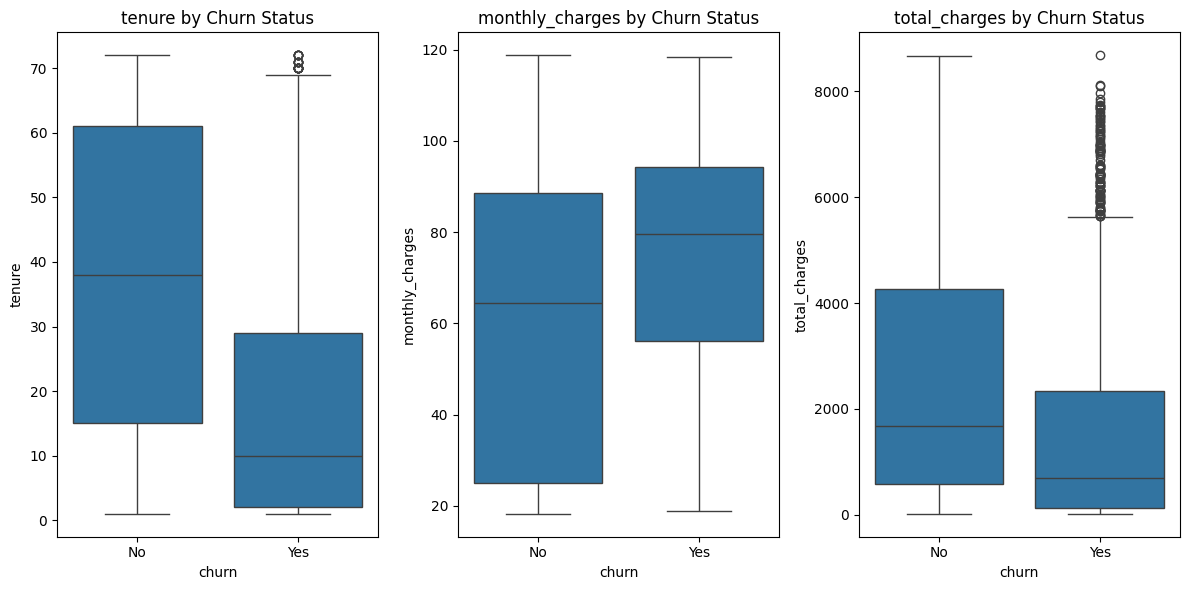

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(12,6))
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='churn', y=col,  ax=axes[i])
    axes[i].set_title(f"{col} by Churn Status")

plt.tight_layout()
plt.show()

In [202]:
# Group the tenure columns into a group
df['tenure_groups'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels = ["0-1 Year", "1-2 Years", "2-4 Years", "4+ Years"])

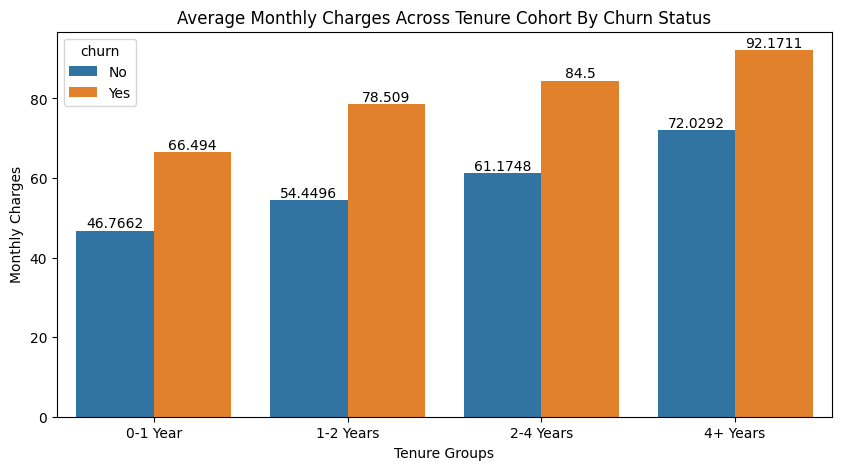

In [203]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x="tenure_groups", y="monthly_charges", hue='churn', data=df, errorbar=None)

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Average Monthly Charges Across Tenure Cohort By Churn Status")
plt.xlabel("Tenure Groups")
plt.ylabel("Monthly Charges")
plt.show()

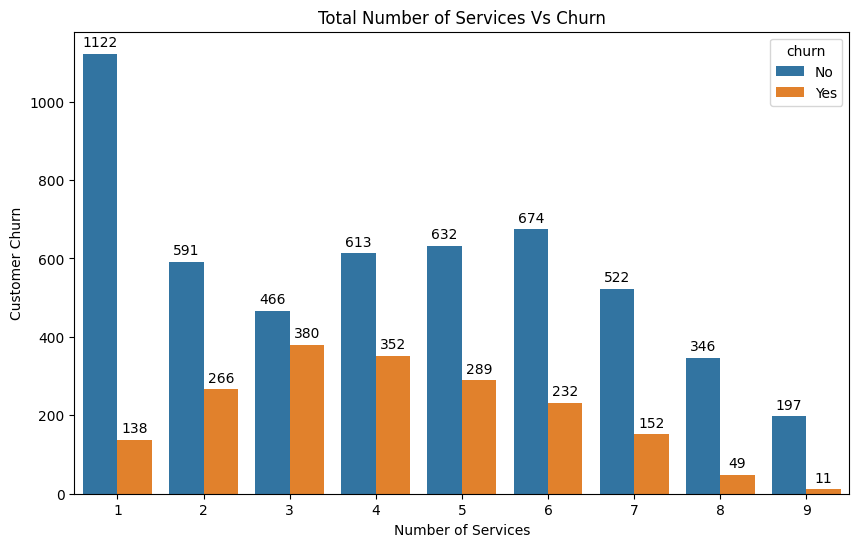

In [204]:
# create a services list
services_cols = ['phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

df['total_services'] = (
    (df['phone_service'] == 'Yes').astype(int) + 
    (df['multiple_lines'] == 'Yes').astype(int) + 
    (df['internet_service'] != 'No').astype(int) + 
    (df['online_security'] == 'Yes').astype(int) + 
    (df['online_backup'] == 'Yes').astype(int) + 
    (df['device_protection'] == 'Yes').astype(int) + 
    (df['tech_support'] == 'Yes').astype(int) + 
    (df['streaming_tv'] == 'Yes').astype(int) + 
    (df['streaming_movies'] == 'Yes').astype(int)
)

plt.figure(figsize = (10,6))
ax = sns.countplot(x='total_services', hue='churn', data=df)
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title("Total Number of Services Vs Churn")
plt.xlabel("Number of Services")
plt.ylabel("Customer Churn")
plt.show()

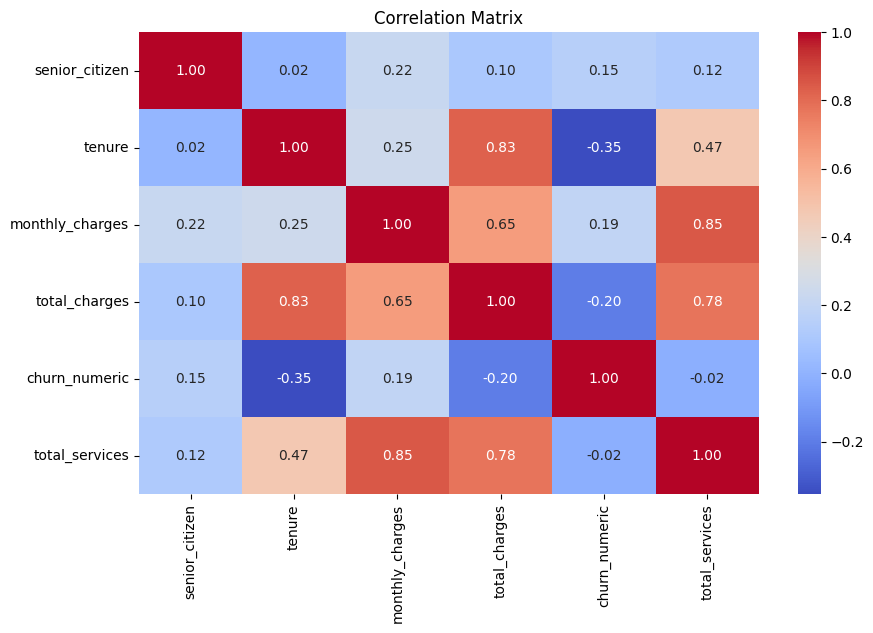

In [205]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot = True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

To check for the correlation relationship between all the numerical features, I plotted correlation matrix. I noticed that total_charges and tenure are highly correlated which means before training machine learning model I need to handle this redundancy. 

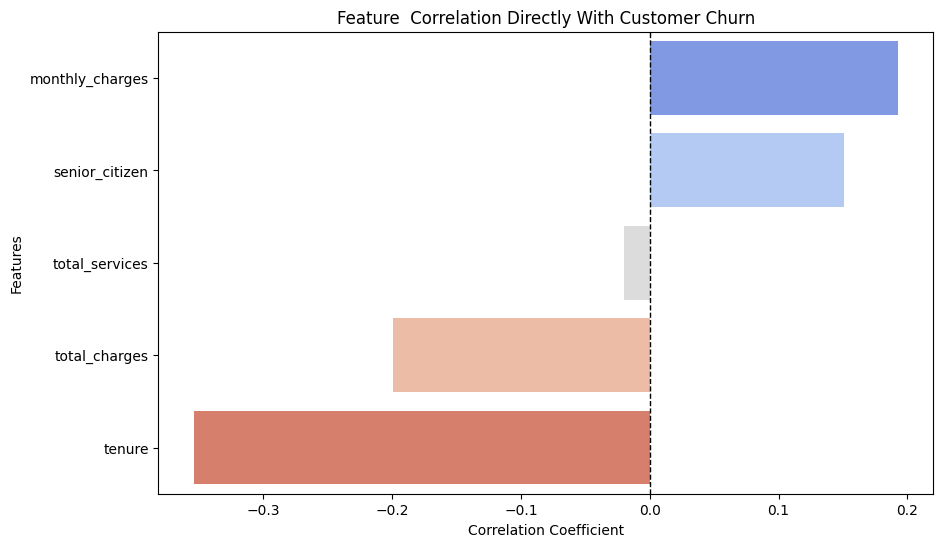

In [206]:
plt.figure(figsize=(10,6))

# Isolate just the correlations relative to churn and sort them 
churn_corr = df.select_dtypes(include=['number']).corr()['churn_numeric'].sort_values(ascending=False)

# Drop the churn column itself so it doesn't correlate with itself
churn_corr = churn_corr.drop('churn_numeric')

# Add a center line
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
sns.barplot(x=churn_corr.values, y=churn_corr.index, hue=churn_corr.index, palette = 'coolwarm', legend=False)
plt.title("Feature  Correlation Directly With Customer Churn")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show() 

To understand how features correlate and impact customer turnover, I plotted a barplot which shows only correlations directly related to churn status. The barplot clearly demonstrates that monthly charges mostly causes customer churn, while tenure is the opposite, which shows the longer the tenure the less the customer churn .